In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt


In [2]:
base = os.path.join(os.getcwd(),'..','compiled values')

In [3]:
lp_abgm_ir = pd.read_excel(os.path.join(base,'LAI_irrigated_compiled.xlsx'))
lp_abgm_rf = pd.read_excel(os.path.join(base,'LAI_rainfed_compiled.xlsx'))
rs_gpp = pd.read_excel(os.path.join(base,'rs_lai_compiled.xlsx'))

In [30]:
def process_lpj(df,param):
    major_corn = ['IOWA','ILLINOIS']
    df = df[df['State_Name'].isin(major_corn)]
    df['month'] = df['date'].apply(lambda x:x.month)
    df['year'] = df['date'].apply(lambda x:x.year)
    df = df.drop(columns=['Unnamed: 0','State_Name','month','date']).groupby('year').mean()
    df.rename(columns={'Mean(SO)':param},inplace=True)
    return df

In [31]:
def process_rs(df,param):
    major_corn = ['IOWA','ILLINOIS']
    df = df[df['State_Name'].isin(major_corn)]
    df = df[(df['year'].isin(range(2010,2020))) & (df['month'].isin(range(4,9)))]
    test = df[df['month'].isin(range(4,9))].drop(columns=['Unnamed: 0','State_Name','month']).groupby('year').mean()*0.1
    test.rename(columns={'mean':param},inplace=True)
    return test

In [32]:
ir = process_lpj(lp_abgm_ir,'LAI(irrigated)')
rf = process_lpj(lp_abgm_rf,'LAI(rainfed)')
rs = process_rs(rs_gpp,'LAI(rs)')
final = pd.merge(ir,rf,on='year')
final = pd.merge(final,rs,on='year')

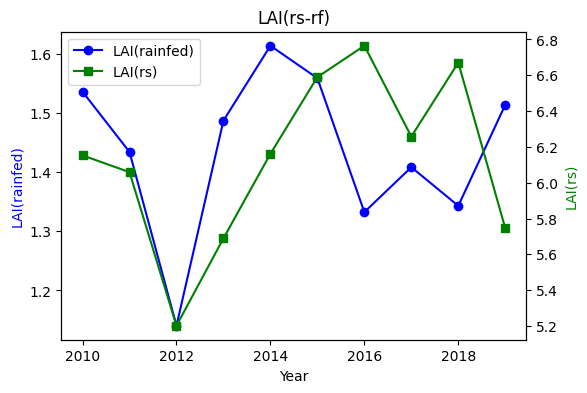

In [42]:
fig, ax1 = plt.subplots(figsize=(6,4))

line1 = ax1.plot(final.index, final['LAI(rainfed)'], color='blue', marker='o', label='LAI(rainfed)')
ax1.set_xlabel('Year')
ax1.set_ylabel('LAI(rainfed)', color='blue')

ax2 = ax1.twinx()
line2 = ax2.plot(final.index, final['LAI(rs)'], color='green', marker='s', label='LAI(rs)')
ax2.set_ylabel('LAI(rs)', color='green')


lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("LAI(rs-rf)")
plt.show()

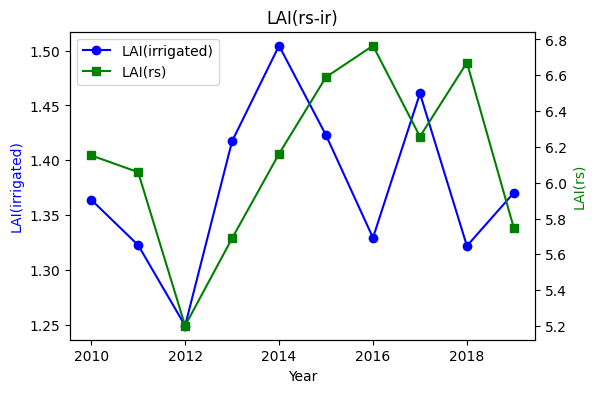

In [43]:
fig, ax1 = plt.subplots(figsize=(6,4))

line1 = ax1.plot(final.index, final['LAI(irrigated)'], color='blue', marker='o', label='LAI(irrigated)')
ax1.set_xlabel('Year')
ax1.set_ylabel('LAI(irrigated)', color='blue')

ax2 = ax1.twinx()
line2 = ax2.plot(final.index, final['LAI(rs)'], color='green', marker='s', label='LAI(rs)')
ax2.set_ylabel('LAI(rs)', color='green')


lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title("LAI(rs-ir)")
plt.show()